# 🚀 Experiment 3: Redundancy & Repetition Check

We will compute three signals:

**1. Repetition Ratio (n-gram repetition)**

Measures textual repetition like:

"comfortable comfortable comfortable"

or

"This product is good. This product is good."

Often spikes in LLM-generated text.

**2. Self-Similarity (embedding redundancy within a document)**
Compute embeddings for every sentence and measure:
   * **High values mean the document says the same thing in different words.**

**3. Unique Sentence Ratio**

* Ratio of unique sentences to total sentences.

In [1]:
#!pip install nltk

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics.pairwise import cosine_similarity
import re
from nltk import ngrams
from tqdm import tqdm
from collections import Counter
from sentence_transformers import SentenceTransformer

In [2]:
# ===============================================================
# 📌 Load E5-small (English-only)
# ===============================================================

model = SentenceTransformer("intfloat/e5-small")


In [3]:
# ---------------------------------
# 1. Load CSV
# ---------------------------------
docs = pd.read_csv("~/work/vector_search/llm_prod_desc_analysis/llm_generated_prod_desc.csv")   # columns: ecode, llm_description_few_shot

# Rename for convenience
docs = docs.rename(columns={"llm_description_few_shot": "text"})

# Drop missing rows
docs = docs.dropna(subset=["text"])

print(f"Loaded {len(docs)} descriptions")


Loaded 179965 descriptions


In [4]:
def repetition_ratio(text, n=2):
    """
    Computes repetition ratio using n-gram frequency.
    n=2 → bigrams, n=3 → trigrams
    """
    tokens = text.lower().split()
    if len(tokens) < n + 1:
        return 0.0
    
    ng = list(ngrams(tokens, n))
    total = len(ng)
    
    counts = {}
    for g in ng:
        counts[g] = counts.get(g, 0) + 1
    
    repeated = sum(1 for k,v in counts.items() if v > 1)
    
    return round((repeated / total),3)


# Token-level Repetition Ratio

This measures:
  repeated tokens / total tokens

In [5]:
def repetition_ratio(text):
    tokens = text.split()
    counts = Counter(tokens)
    repeated = sum(c-1 for c in counts.values() if c > 1)
    return round((repeated / len(tokens)),3) if tokens else 0

docs["repetition_ratio"] = docs["text"].apply(repetition_ratio)


# N-gram Repetition (Phrase-level)

In [6]:
def ngram_repetition(text, n=2):
    tokens = text.split()
    if len(tokens) < n:
        return 0
    ngrams = [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    counts = Counter(ngrams)
    repeated = sum(c-1 for c in counts.values() if c > 1)
    return round((repeated / len(ngrams)),3)

docs["bigram_repetition"] = docs["text"].apply(lambda x: ngram_repetition(x, n=2))
# 2. Trigram Repetition (The "Looping" Detector) 
# This is main weapon against LLM degeneration.
docs["trigram_repetition"] = docs["text"].apply(lambda x: ngram_repetition(x, n=3))


# Self-Similarity of Sentences

In [7]:
def compute_self_similarity(text, model):
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if len(s.strip()) > 0]
    
    if len(sentences) < 2:
        return 0.0
    
    with torch.no_grad():
        embeddings = model.encode(sentences, convert_to_tensor=True).cpu().numpy()
    
    sim_matrix = cosine_similarity(embeddings)
    
    # remove diagonal (self matches)
    mask = ~np.eye(len(sim_matrix), dtype=bool)
    
    return round(sim_matrix[mask].mean(),3)


# Run the Redundancy Experiment Over DataFrame docs

In [8]:
docs["self_similarity"] = docs["text"].apply(lambda x: compute_self_similarity(x, model))


In [9]:
docs["is_garbage"] = (
    (docs["repetition_ratio"] > 0.50) |       # Single word repetition (relaxed to 0.5)
    (docs["bigram_repetition"] > 0.35) |      # Grammatical redundancy (relaxed)
    (docs["trigram_repetition"] > 0.15) |     # Semantic looping (Strict!)
    (docs["self_similarity"] > 0.80)
)

In [10]:
# Compute thresholds dynamically
rep_p95  = np.percentile(docs["repetition_ratio"], 95)
bi_p95   = np.percentile(docs["bigram_repetition"], 95)
tri_p90  = np.percentile(docs["trigram_repetition"], 90)
sim_p97  = np.percentile(docs["self_similarity"], 97)
sim_p97 = round(sim_p97,3)
print("Thresholds:")
print("Repetition Ratio (95th):", rep_p95)
print("Bigram Repetition (95th):", bi_p95)
print("Trigram Repetition (90th):", tri_p90)
print("Self Similarity (97th):", sim_p97)


Thresholds:
Repetition Ratio (95th): 0.33
Bigram Repetition (95th): 0.09
Trigram Repetition (90th): 0.024
Self Similarity (97th): 0.862


In [11]:
docs["is_garbage"] = (
    (docs["repetition_ratio"] > rep_p95) |
    (docs["bigram_repetition"] > bi_p95) |
    (docs["trigram_repetition"] > tri_p90) |
    (docs["self_similarity"] > sim_p97)
)


In [12]:
docs[docs["is_garbage"]].shape[0]

24883

# Flag High-Redundancy Docs

In [16]:
#docs["is_redundant"] = docs["repetition_ratio"] > 0.50
#docs["is_looping"] = docs["bigram_repetition"] > 0.35

docs[docs["is_garbage"]].shape[0]

168847

In [21]:
docs.sort_values("repetition_ratio", ascending=False).head(100)

,ecode,text,repetition_ratio,bigram_repetition,trigram_repetition,self_similarity,is_garbage
87530,W14MXFLDUALWRBRSH,The Maxfli Dual-Sided Brush is a golf bag acce...,0.463,0.150,0.075,0.879,True
7133,23TIXYYTHVLLYBLLTLAX,The GOAT USA Youth Volleyball T-Shirt is a you...,0.463,0.152,0.090,0.859,True
165233,25GIAUCYCLRCNTLRCKZPO,The Giant Recon TL Rack Mount is a bike light ...,0.457,0.106,0.019,0.863,True
162721,24SHUYSCHTTHSSJWPFTBA,The Schutt HSS Jaw Pads (Pair) are a helmet pa...,0.454,0.127,0.034,0.912,True
117584,24ADIARX31H38XXXXRCQ,The adidas RX 3.1 H38 Beach Tennis Racquet is ...,0.452,0.136,0.073,0.828,True
...,...,...,...,...,...,...,...
162170,24PNGUPNGPP58TRLPGRP,The PING PP58 Tour Putter Grip is a unisex gol...,0.410,0.141,0.061,0.853,True
68402,17ECLUBSSHKSSTXXXTER,The Eagle Claw Bass Hook Assortment is a unise...,0.409,0.126,0.070,0.878,True
178334,25CMBMMLBDDGRSBLWMLB,The Columbia Men's Los Angeles Dodgers 2025 Wo...,0.409,0.172,0.140,0.827,True
21821,23JLOWWMNSMLDDFLPFOT,The CALIA Women's Molded Flip Flop is a women'...,0.409,0.141,0.088,0.886,True


# Visualize Top 100 Most Repetitive Docs

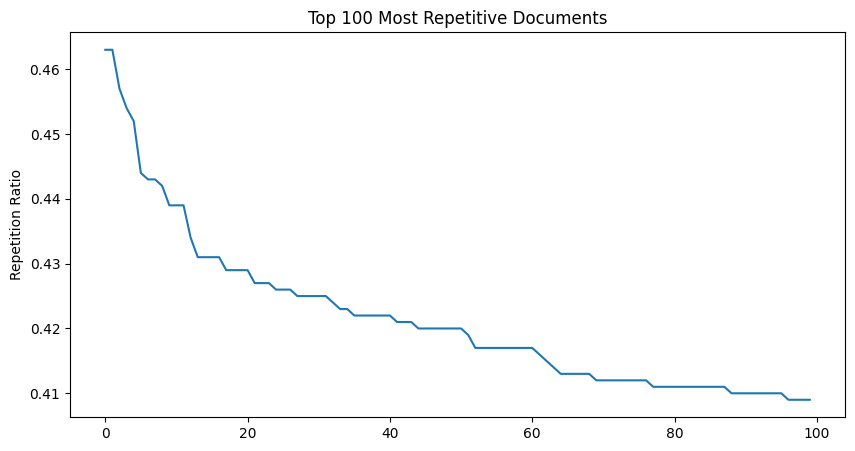

In [13]:
df_top_repetitive = docs.sort_values("repetition_ratio", ascending=False).head(100)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df_top_repetitive["repetition_ratio"].values)
plt.ylabel("Repetition Ratio")
plt.title("Top 100 Most Repetitive Documents")
plt.show()


In [22]:
#Export Top 100 Repetitive Documents to CSV
# Sort by repetition_ratio descending
#top_rep = docs.sort_values(by="repetition_ratio", ascending=False).head(100)
top_rep = docs[docs["is_garbage"]]
# Save to CSV
top_rep.to_csv("top_100_repetitive_garbage_ecodes.csv", index=False)

top_rep.head()


,ecode,text,repetition_ratio,bigram_repetition,trigram_repetition,self_similarity,is_garbage
17,25WILMBASE2000T1D1ONA,The Wilson 11.75'' T1D 1724 A2000 SuperSkin Se...,0.284,0.048,0.027,0.829,True
23,25WNCUNCWSC3X5CLGNHG,The WinCraft Wisconsin Badgers 3' X 5' College...,0.333,0.070,0.035,0.826,True
25,25WNCUNFLCHFS3X5FNFH,The WinCraft Kansas City Chiefs 3' X 5' Flag i...,0.305,0.062,0.037,0.862,True
27,25WNCUNFLCRDS11X1NFHA,"The WinCraft Arizona Cardinals 11"" X 17"" Chevr...",0.367,0.101,0.045,0.842,True
28,25WNCUNFLSTLRS3X5NFH,The WinCraft Pittsburgh Steelers 3' X 5' Flag ...,0.316,0.067,0.027,0.866,True


# Visualizations

In [15]:
import matplotlib.pyplot as plt
redund_df["bigram_repetition"].hist(bins=50, figsize=(6,4))
plt.title("Histogram of Bigram Repetition Ratio")
plt.show()


NameError: name 'redund_df' is not defined

# Histogram – Self-Similarity

In [ ]:
redund_df["self_similarity"].hist(bins=50, figsize=(6,4))
plt.title("Self-Similarity Distribution")
plt.show()


# Scatter – Self-Similarity vs Repetition

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(
    redund_df["self_similarity"], 
    redund_df["bigram_repetition"], 
    alpha=0.3
)
plt.xlabel("Self Similarity")
plt.ylabel("Bigram Repetition")
plt.title("Repetition vs Self-Similarity")
plt.show()
